<a href="https://colab.research.google.com/github/liaalcantara01/CDA-UTEC/blob/main/Lab7_1_fundamentalML_Peru.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fundamentos de Machine Learning
## Ciencia de Datos Ambientales – Aplicado al Perú

**Duración:** 75 minutos

Lectura recomendada: Andriy Burkov, *The Hundred-Page Machine Learning Book*

---

### Objetivos de aprendizaje

1. Distinguir aprendizaje supervisado, no supervisado y por refuerzo, e identificar cuál aplica a un problema ambiental dado.
2. Explicar la configuración matemática de la regresión lineal y logística.
3. Aplicar el flujo de trabajo estándar de `scikit-learn`: cargar → preprocesar → dividir → entrenar → evaluar.
4. Interpretar una matriz de confusión y calcular exactitud, precisión, recall y F1.
5. Reconocer sobreajuste vs. subajuste y explicar por qué la división entrenamiento/prueba es esencial.

## 1. ¿Qué es el Machine Learning?

El aprendizaje automático (ML) es el proceso de construir algoritmos que **aprenden patrones de los datos** en lugar de ser programados explícitamente con reglas.

El flujo de trabajo general es:
1. **Reunir un dataset** de ejemplos que representen algún fenómeno de interés.
2. **Elegir y entrenar un modelo estadístico** que capture la estructura en los datos.
3. **Usar el modelo entrenado** para hacer predicciones en datos nuevos no vistos.

### ¿Por qué importa el ML para la ciencia ambiental?

Los conjuntos de datos ambientales suelen ser de alta dimensionalidad (muchas bandas espectrales, muchas especies, muchas variables climáticas) y presentan relaciones complejas y no lineales. El aprendizaje automático proporciona herramientas para:

- clasificar tipos de cobertura terrestre a partir de imágenes satelitales,
- predecir el riesgo de incendios forestales a partir de datos meteorológicos y de humedad del combustible,
- pronosticar la distribución de especies en el contexto del cambio climático,
- completar datos faltantes en mediciones de flujo por covarianza de remolinos.

### Tipos de aprendizaje

![Types of Machine Learning](https://miro.medium.com/v2/resize:fit:1400/format:webp/1*6iDmbHflsN6NULBLpVHA6A.png)

Existen tres paradigmas principales de aprendizaje automático:

| Paradigma | Datos de entrada | Meta | Ejemplo ambiental peruano |
|-----------|-----------------|------|---------------------------|
| **Supervisado** | Ejemplos etiquetados $(\mathbf{x}_i, y_i)$ | Predecir etiqueta $y$ para nuevo $\mathbf{x}$ | Clasificar píxeles como bosque / cultivo / agua |
| **No supervisado** | Ejemplos sin etiquetar $\mathbf{x}_i$ | Descubrir estructura o grupos | Agrupar cuencas hidrográficas similares |
| **Por refuerzo** | Estados, acciones, recompensas | Aprender política que maximiza recompensa | Optimizar gestión de reservas de agua, Optimizar la programación de las quemas controladas. |

En esta clase nos centraremos en el **aprendizaje supervisado** porque es la base de la mayoría de las tareas de modelado predictivo en la ciencia de datos ambientales.

### Aprendizaje Supervisado

En el aprendizaje supervisado, comenzamos con un **conjunto de datos etiquetado** de $N$ ejemplos:

$$\{(\mathbf{x}_i,\; y_i)\}_{i=1}^{N}$$

- $\mathbf{x}_i \in \mathbb{R}^M$ es un **vector de características** con $M$ atributos que describen la $i$-ésima observación.

- $y_i$ es la **etiqueta**, ya sea una clase discreta (clasificación) o un valor continuo (regresión).

#### Ejemplo ecológico

Supongamos que creamos un conjunto de datos que describe parcelas forestales:

| Característica | Descripción |
|----------------|-------------|
| Temperatura media anual (°C) | Clima |
| Precipitación anual (mm) | Clima |
| Altitud (msnm) | Topografía |
| NDVI (sin unidades) | Teledetección |
| Pendiente (°) | Terreno |
| Altura de la cubierta o canopy (m) | Estructura |

La etiqueta $y_i$ podría ser:
- **Clasificación:** tipo de bosque dominante (amazónico, andino, seco, mangle)
- **Regresión:** biomasa aérea (Mg C ha⁻¹)

> **Pregunta para debatir:** ¿Qué representan $\mathbf{x}_i$ e $y_i$ si queremos predecir la presencia/ausencia de una especie a partir de covariables ambientales?

El objetivo de un algoritmo de aprendizaje supervisado es generar un modelo $f$ tal que $f(\mathbf{x}) \approx y$ para observaciones *nuevas* no vistas durante el entrenamiento.

### Aprendizaje no supervisado

En el aprendizaje no supervisado, el conjunto de datos contiene únicamente vectores de características — **sin etiquetas**:

$$
\{\mathbf{x}_i\}_{i=1}^{N}
$$

El objetivo es descubrir estructuras ocultas como clústeres, dimensiones latentes o patrones de densidad. Aplicaciones comunes en ciencias ambientales:

- **Agrupación** de píxeles de teledetección en grupos espectralmente similares (clasificación no supervisada).

- **Reducción de dimensionalidad** (PCA) para resumir datos de comunidades multivariadas.

- **Detección de anomalías** para identificar fallos en sensores en datos de torres de flujo.

### Aprendizaje por Refuerzo (breve introducción)

En el aprendizaje por refuerzo (AR), un **agente** interactúa con un **entorno** realizando acciones y recibiendo recompensas. El objetivo es aprender una **política** —una correspondencia entre estados y acciones— que maximice la recompensa acumulada a largo plazo.

El AR es menos común en la ciencia de datos ambientales cotidiana, pero se utiliza en áreas como la gestión adaptativa de recursos naturales, el muestreo ambiental robótico y el control de riego en tiempo real. No implementaremos el AR en este curso, pero es importante que conozcan este paradigma.

## 2. Algoritmos ML Comunes

Aquí tienes una lista (no exhaustiva) de algoritmos con los que te encontrarás, organizada por tarea:

| Clasificación | Regresión | Clustering |
|---------------|-----------|------------|
| Regresión Logística | Regresión Lineal | K-Means |
| Máquina de Soporte Vectorial (SVM) | Ridge / Lasso | Clustering Jerárquico |
| Árbol de Decisión / Random Forest | Árbol de Decisión / RF | DBSCAN |
| K-Vecinos más Cercanos (KNN) | Gradient Boosting | Mezcla Gaussiana |
| Redes Neuronales Artificiales (ANN)| Redes Neuronales Artificiales (ANN)| — |

En esta clase, analizaremos en detalle la **regresión lineal** y la **regresión logística**. En clases posteriores, abordaremos los métodos basados ​​en árboles y otros enfoques.

### 2.1 Regresión Lineal

Predice una respuesta continua $y$ como función lineal del vector de características $\mathbf{x}$:

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b$$

donde $\mathbf{w}$ es un vector de **pesos** (uno por característica) y $b$ es un término de **sesgo** (intercepto).

### **Funciones de pérdida:**

Para entrenar el modelo, necesitamos una medida de la diferencia entre las predicciones $\hat{y}_i$ y los valores reales $y_i$. Dos opciones comunes son:

**Error Absoluto Medio (MAE):**

$$
\text{MAE} = \frac{1}{N}\sum_{i=1}^{N} |\hat{y}_i - y_i|

$$

**Error Cuadrático Medio (MSE):**

$$
\text{MSE} = \frac{1}{N}\sum_{i=1}^{N} (\hat{y}_i - y_i)^2
$$

El MSE se usa con más frecuencia porque es diferenciable en todo su dominio, lo que simplifica la optimización mediante descenso de gradiente. Además, elevar al cuadrado penaliza más los errores grandes.

Entrenar un modelo de regresión lineal implica encontrar $\mathbf{w}$ y $b$ que minimicen la función de pérdida elegida (también llamada función de costo $J(\mathbf{w}, b)$).

> **Nota sobre la convención 1/2:** Algunos libros de texto escriben el MSE con un factor de $\frac{1}{2N}$ en lugar de $\frac{1}{N}$. El $\frac{1}{2}$ es una convención que simplifica el cálculo del exponente al derivar durante el descenso de gradiente; el valor óptimo de $\mathbf{w}$ es el mismo en ambos casos.

Pendiente (w):                0.0253 m³/s por mm
Intercepto (b):               -0.13
Error cuadrático medio (MSE): 69.42
R²:                           0.821


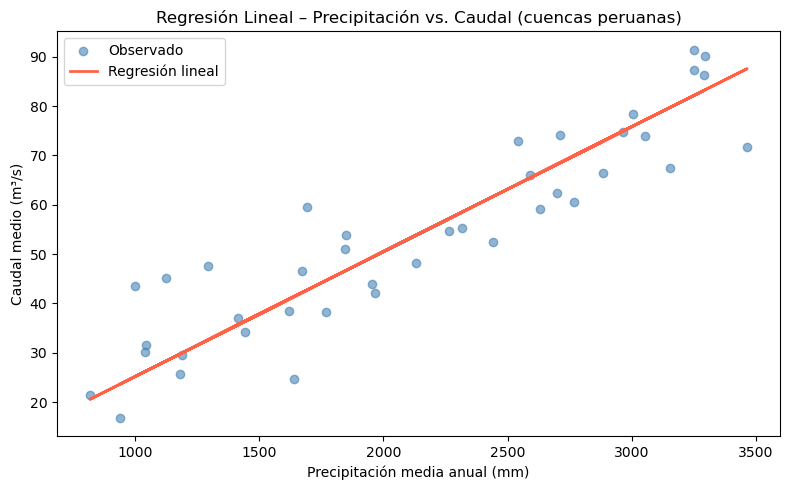

In [ ]:
# === Regresión Lineal: Precipitación vs. Caudal en Cuencas Peruanas ===
# Dataset sintético basado en características hidrológicas peruanas

import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

np.random.seed(42)
n = 200

# Precipitación media anual (mm) – rango típico de cuencas andino-amazónicas
precipitacion = np.random.uniform(800, 3500, n)
# Caudal medio (m³/s) – relación aproximada más ruido
caudal = 0.025 * precipitacion + np.random.normal(0, 8, n)
caudal = np.maximum(caudal, 0)

X_precip = precipitacion.reshape(-1, 1)

# Dividir en entrenamiento y prueba (80/20)
X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X_precip, caudal, test_size=0.20, random_state=42
)

# Crear y entrenar el modelo
modelo = LinearRegression()
modelo.fit(X_entrena, y_entrena)

# Predecir en el set de prueba
y_pred = modelo.predict(X_prueba)

# Evaluar el modelo
print(f"Pendiente (w):                {modelo.coef_[0]:.4f} m³/s por mm")
print(f"Intercepto (b):               {modelo.intercept_:.2f}")
print(f"Error cuadrático medio (MSE): {mean_squared_error(y_prueba, y_pred):.2f}")
print(f"R²:                           {r2_score(y_prueba, y_pred):.3f}")

# Visualizar
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(X_prueba, y_prueba, color='steelblue', alpha=0.6, label='Observado')
ax.plot(X_prueba, y_pred, color='tomato', linewidth=2, label='Regresión lineal')
ax.set_xlabel('Precipitación media anual (mm)')
ax.set_ylabel('Caudal medio (m³/s)')
ax.set_title('Regresión Lineal – Precipitación vs. Caudal (cuencas peruanas)')
ax.legend()
plt.tight_layout()
plt.show()

### 2.2 Regresión Logística

A pesar de su nombre, la **regresión logística** es un algoritmo de clasificación, no una regresión. Su nombre proviene del hecho de que extiende la regresión lineal con la **función logística (sigmoide)**.

#### ¿Por qué no usar simplemente una función lineal para la clasificación?

Si nuestras etiquetas son binarias ($y ∈ {0, 1}$), un modelo lineal simple $\hat{y} = \mathbf{w}^\top\mathbf{x} + b$ puede producir cualquier número real; no está naturalmente acotado entre 0 y 1. Necesitamos una forma de mapear la salida lineal a una probabilidad.

#### La función sigmoide

La **función logística estándar (sigmoide)** comprime cualquier valor real dentro del intervalo $(0, 1)$:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Al aplicar esto al modelo lineal, obtenemos el modelo de regresión logística:

$$
P(y=1 \mid \mathbf{x}) = \sigma(\mathbf{w}^\top \mathbf{x} + b) = \frac{1}{1 + e^{-(\mathbf{w}^\top \mathbf{x} + b)}}
$$

#### ¿Qué significa cada variable?

| Variable | Nombre | Significado |
|---|---|---|
| **x** | vector de características | datos de entrada (ej: temperatura, pH, precipitación) |
| **w** | pesos (weights) | cuánto influye cada característica en la predicción |
| **w⊤** | w transpuesto | multiplicación entre pesos y características |
| **b** | sesgo (bias) | ajuste base, como el intercepto en y = mx + b |
| **P(y=1 \| x)** | probabilidad | chance de que ocurra el evento, dados los datos x |

#### Interpretación
Interpretamos el resultado como la **probabilidad** de que la observación pertenezca a la clase positiva. Una regla de decisión común es:

$$
\hat{y} = \begin{cases} 1 & \text{si } P(y=1 \mid \mathbf{x}) \geq 0.5 \\ 0 & \text{en otro caso} \end{cases}
$$

El umbral de 0.5 se puede ajustar según el costo de los falsos positivos frente a los falsos negativos; por ejemplo, en la detección de especies raras, se podría reducir el umbral para evitar pasar por alto presencias reales.

#### Comparación de la regresión lineal y logística

| Comparación | Regresión lineal | Regresión logística |
|---|---|---|
| **Tarea** | Regresión (variable continua $y$) | Clasificación (variable discreta $y$) |
| **Resultado del modelo** | Valor real no acotado | Probabilidad en $(0, 1)$ |
| **Función de pérdida** | Error cuadrático medio | Entropía cruzada (pérdida logarítmica) |
| **Ejemplo** | Predecir el caudal de un arroyo a partir de la lluvia | Clasificar humedales frente a tierras altas a partir de datos espectrales |

#### Ejemplo: ¿El ecosistema está en riesgo?

Queremos predecir si una zona de manglar **está en riesgo de degradación** (1 = sí, 0 = no).

**Datos de entrada (x):**

| Característica | Valor |
|---|---|
| Temperatura del agua (°C) | 31.5 |
| Salinidad (ppt) | 42.0 |
| Nivel de sedimento (mg/L) | 180.0 |

**Pesos aprendidos (w) y sesgo (b):**

$$
\mathbf{w} = [0.4,\ 0.6,\ 0.9], \quad b = -2.1
$$

> El modelo aprendió que el sedimento (0.9) y la salinidad (0.6)
> son los factores más críticos para la degradación.

**Combinación lineal:**

$$
z = (0.4 \times 31.5) + (0.6 \times 42.0) + (0.9 \times 180.0) - 2.1 = 12.6 + 25.2 + 162.0 - 2.1 = 197.7
$$

**Aplicar sigmoide:**

$$
\sigma(197.7) = \frac{1}{1 + e^{-197.7}} \approx 0.98
$$

**Resultado:** el modelo estima un **98% de probabilidad de degradación** → zona en riesgo crítico.

#### El flujo completo

```
x (temp, salinidad, sedimento)
    → w⊤x + b (combinación lineal)
    → σ( ) (sigmoide)
    → probabilidad entre 0 y 1
    → si > 0.5 → zona en riesgo
```

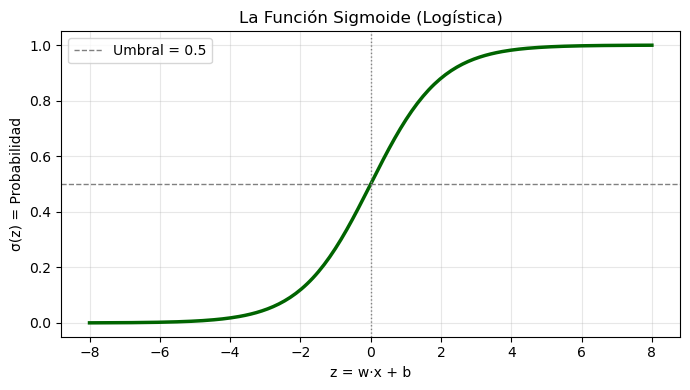

In [ ]:
# Visualizar la función sigmoide
import numpy as np
import matplotlib.pyplot as plt

z = np.linspace(-8, 8, 200)
sigma = 1 / (1 + np.exp(-z))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(z, sigma, color='darkgreen', linewidth=2.5)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='Umbral = 0.5')
ax.axvline(0, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('z = w·x + b')
ax.set_ylabel('σ(z) = Probabilidad')
ax.set_title('La Función Sigmoide (Logística)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 3. El Flujo de Trabajo de `scikit-learn`

[`scikit-learn`](https://scikit-learn.org/) (importado como `sklearn`) proporciona una API consistente para construir modelos de aprendizaje automático en Python. El flujo de trabajo típico es:

```
Cargar datos → Preprocesar → Dividir (Train/test/validation) → Instanciar modelo → Ajustar → Predecir → Evaluar
```

Pasos clave en detalle:

1. **Importar** los módulos relevantes (`sklearn.model_selection`, `sklearn.preprocessing`, el estimador elegido y las métricas de evaluación).

2. **Cargar y explorar** los datos: comprobar si hay valores faltantes, el equilibrio de clases y la distribución de las características.

3. **Preprocesar**: gestionar los datos faltantes, codificar las variables categóricas y escalar las características si es necesario (muchos algoritmos son sensibles a la magnitud de las características).

4. **Dividir** los datos en conjuntos de entrenamiento y prueba con `train_test_split`. El conjunto de prueba debe reservarse y **nunca** utilizarse durante el entrenamiento o la optimización del modelo.

5. **Instanciar y ajustar** el modelo (`.fit(X_train, y_train)`).

6. **Realizar predicciones** sobre el conjunto de prueba (`.predict(X_test)`).
7. **Evalúa** con las métricas adecuadas (precisión, MSE, R², etc.).

8. **Itera**: prueba diferentes preprocesamientos, modelos o hiperparámetros.

Apliquemos este flujo de trabajo a ejemplos completos.


### Ejemplo 1: Predicción del caudal (regresión)

Ya lo vimos anteriormente. El patrón de código clave es:

```python
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R²: ", r2_score(y_test, y_pred))
```

### Ejemplo 2: Clasificación de especies de iris (clasificación)

El conjunto de datos clásico de iris contiene cuatro mediciones de pétalos/sépalos para 150 flores de tres especies. Este es un problema de clasificación multiclase.

Clásico dataset de flores con:
- 150 muestras,
- 3 especies,
- 4 características (largo/ancho de pétalos y sépalos).

In [ ]:
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics

# ── Cargar datos ──
iris = load_iris()
X, y = iris.data, iris.target
print(f"Características: {iris.feature_names}")
print(f"Clases: {iris.target_names}")
print(f"Forma del conjunto de datos: {X.shape} (N={X.shape[0]} muestras, M={X.shape[1]} características)\n")

# ── División de entrenamiento/prueba (75 % entrenamiento, 25 % prueba) ──
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.25, random_state=0
)

# ── Instanciar y entrenar ──
# max_iter=200 garantiza la convergencia para este conjunto de datos
logreg = LogisticRegression(max_iter=200)
logreg.fit(X_train, y_train)

# ── Predecir y evaluar ──
y_pred = logreg.predict(X_test)

accuracy = metrics.accuracy_score(y_test, y_pred)
print(f"Precisión general: {accuracy:.2%}\n")
print("Informe de clasificación:")
print(metrics.classification_report(y_test, y_pred, target_names=iris.target_names))

Características: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Clases: ['setosa' 'versicolor' 'virginica']
Forma del conjunto de datos: (150, 4) (N=150 muestras, M=4 características)

Precisión general: 97.37%

Informe de clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.94      0.97        16
   virginica       0.90      1.00      0.95         9

    accuracy                           0.97        38
   macro avg       0.97      0.98      0.97        38
weighted avg       0.98      0.97      0.97        38



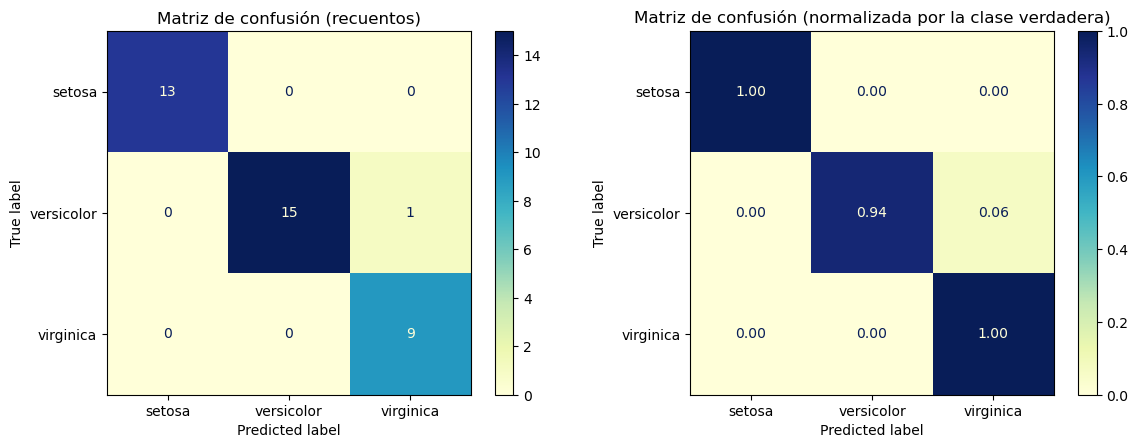

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

# ── Visualiza la matriz de confusión del clasificador Iris ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Recuentos brutos
ConfusionMatrixDisplay.from_predictions(
y_test, y_pred,
display_labels=iris.target_names,
cmap="YlGnBu",
ax=axes[0]
)
axes[0].set_title("Matriz de confusión (recuentos)")

# Normalizada (fila por fila → recuperación por clase)
ConfusionMatrixDisplay.from_predictions(
y_test, y_pred,
display_labels=iris.target_names,
normalize="true",
cmap="YlGnBu",

ax=axes[1],

values_format=".2f"
)
axes[1].set_title("Matriz de confusión (normalizada por la clase verdadera)")

plt.tight_layout()
plt.show()

### Ejemplo 3: Clasificar calidad del agua en Perú

In [ ]:
# === Clasificación de Calidad del Agua con Regresión Logística ===
# Dataset inspirado en datos de monitoreo de ríos peruanos (ANA/OEFA)
# Variables: pH, Turbidez, OD, DBO, Coliformes → Apta/No Apta

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

np.random.seed(42)
n_muestras = 300

# Generar dataset sintético de calidad de agua
ph           = np.random.normal(7.2, 0.8, n_muestras)
turbidez     = np.random.exponential(10, n_muestras)  # NTU
od           = np.random.normal(7.5, 1.5, n_muestras) # mg/L
dbo          = np.random.exponential(5, n_muestras)   # mg/L
coliformes   = np.random.exponential(100, n_muestras) # UFC/100mL

# Etiqueta: 1=apta, 0=no apta
puntuacion_calidad = (
    (ph > 6.5).astype(float) * 0.3 +
    (turbidez < 15).astype(float) * 0.2 +
    (od > 5).astype(float) * 0.25 +
    (dbo < 8).astype(float) * 0.15 +
    (coliformes < 200).astype(float) * 0.1 +
    np.random.normal(0, 0.1, n_muestras)
)
calidad = (puntuacion_calidad >= 0.6).astype(int)

df_agua = pd.DataFrame({
    'pH': ph,
    'Turbidez_NTU': turbidez,
    'OD_mgL': od,
    'DBO_mgL': dbo,
    'Coliformes_UFC': coliformes,
    'apta': calidad
})

print(f"Dataset calidad de agua: {len(df_agua)} muestras")
print(f"Balance: {calidad.sum()} aptas ({100*calidad.mean():.0f}%), {(~calidad.astype(bool)).sum()} no aptas")
df_agua.describe().round(2)

Dataset calidad de agua: 300 muestras
Balance: 266 aptas (89%), 34 no aptas


,pH,Turbidez_NTU,OD_mgL,DBO_mgL,Coliformes_UFC,apta
count,300.00,300.00,300.00,300.00,300.00,300.00
mean,7.20,10.63,7.47,5.41,100.66,0.89
std,0.79,11.38,1.48,5.53,101.47,0.32
min,4.61,0.11,3.45,0.03,0.50,0.00
25%,6.65,2.74,6.55,1.33,28.28,1.00
50%,7.25,6.80,7.53,3.87,73.28,1.00
75%,7.70,14.69,8.44,7.40,128.94,1.00
max,10.28,81.72,11.45,30.91,744.17,1.00


In [ ]:
# Dividir y entrenar
X = df_agua[['pH', 'Turbidez_NTU', 'OD_mgL', 'DBO_mgL', 'Coliformes_UFC']].values
y = df_agua['apta'].values

X_entrena, X_prueba, y_entrena, y_prueba = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# Escalar (importante para regresión logística)
escalador = StandardScaler()
X_entrena_e = escalador.fit_transform(X_entrena)
X_prueba_e  = escalador.transform(X_prueba)

# Regresión Logística
reg_log = LogisticRegression(max_iter=300)
reg_log.fit(X_entrena_e, y_entrena)
y_pred = reg_log.predict(X_prueba_e)

exactitud = metrics.accuracy_score(y_prueba, y_pred)
print(f"Exactitud global: {exactitud:.2%}\n")
print("Reporte de clasificación:")
print(metrics.classification_report(y_prueba, y_pred,
                                     target_names=['No Apta', 'Apta']))

Exactitud global: 89.33%

Reporte de clasificación:
              precision    recall  f1-score   support

     No Apta       1.00      0.11      0.20         9
        Apta       0.89      1.00      0.94        66

    accuracy                           0.89        75
   macro avg       0.95      0.56      0.57        75
weighted avg       0.90      0.89      0.85        75



## 4. Evaluar Clasificadores: La Matriz de Confusión

Una **matriz de confusión** resume los resultados comparando etiquetas predichas con etiquetas reales.

|   Real \ Predicho  | Predicho Positivo | Predicho Negativo |
|---|---|---|
| **Realmente Positivo** | Verdadero Positivo (VP) | Falso Negativo (FN) — *Error tipo II* |
| **Realmente Negativo** | Falso Positivo (FP) — *Error tipo I* | Verdadero Negativo (VN) |

$$\text{Exactitud} = \frac{VP + VN}{VP + VN + FP + FN}$$

$$\text{Precision} = \frac{VP}{VP + FP} \qquad \text{Recall} = \frac{VP}{VP + FN}$$

$$\text{F1} = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$


#### ¿Por qué no solo usar exactitud?
En monitoreo ambiental peruano, **las clases suelen ser desequilibradas**. Por ejemplo, si el 95% de los días no hay un evento de contaminación, un modelo que siempre predice "sin contaminación" tiene 95% de exactitud pero 0% de recall para el evento que nos importa. Precisión, recall y F1 dan una imagen más honesta.

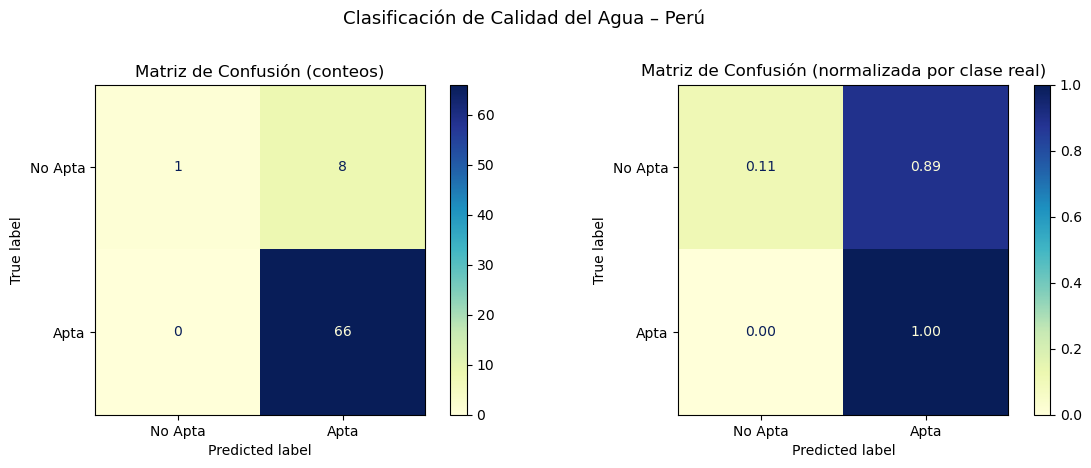

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

# Conteos absolutos
ConfusionMatrixDisplay.from_predictions(
    y_prueba, y_pred,
    display_labels=['No Apta', 'Apta'],
    cmap='YlGnBu',
    ax=ejes[0]
)
ejes[0].set_title('Matriz de Confusión (conteos)')

# Normalizada
ConfusionMatrixDisplay.from_predictions(
    y_prueba, y_pred,
    display_labels=['No Apta', 'Apta'],
    normalize='true',
    cmap='YlGnBu',
    ax=ejes[1],
    values_format='.2f'
)
ejes[1].set_title('Matriz de Confusión (normalizada por clase real)')

plt.suptitle('Clasificación de Calidad del Agua – Perú', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## 5. Sobreajuste, Subajuste y el Tradeoff Sesgo-Varianza

### Subajuste (alto sesgo)
El modelo es demasiado simple para capturar el patrón real. Error de entrenamiento **y** de prueba son altos.

**Ejemplo:** ajustar una línea recta a la relación no lineal entre riqueza de especies y elevación.

### Sobreajuste (alta varianza)
El modelo memoriza el ruido de los datos de entrenamiento. Error de entrenamiento muy bajo, error de prueba alto.

**Ejemplo:** un árbol de decisión sin límite de profundidad que clasifica perfectamente cada píxel de entrenamiento pero falla en imágenes nuevas.

### Salvaguardas prácticas
- **División entrenamiento/prueba:** Siempre reservar una porción de datos (20–30%) que el modelo nunca ve durante el entrenamiento.
- **Validación cruzada:** Repetir la división $k$ veces para una estimación más robusta.
- **Regularización:** Penalizar pesos grandes (L1/L2) para desincentivar modelos demasiado complejos.

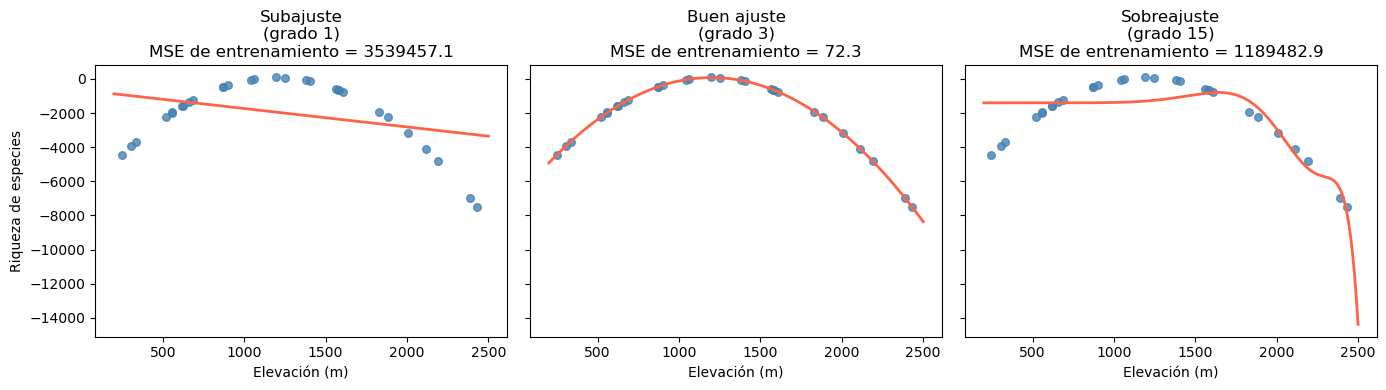

In [ ]:
# === Demostración de sobreajuste: regresión polinómica ===
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# Generar datos sintéticos "ecológicos": riqueza de especies vs. altitud

# Riqueza de especies = el número total de especies distintas en un área o muestra.

np.random.seed(42)
n = 30
elevation = np.sort(np.random.uniform(200, 2500, n))

# La relación real es una curva en forma de joroba (común en ecología)
riqueza_verdadera = -0.005 * (elevation - 1200)**2 + 80
riqueza = riqueza_verdadera + np.random.normal(0, 10, n)

X = elevation.reshape(-1, 1)
elev_fine = np.linspace(200, 2500, 300).reshape(-1, 1)

fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
degrees = [1, 3, 15]
labels = ["Subajuste\n(grado 1)", "Buen ajuste\n(grado 3)", "Sobreajuste\n(grado 15)"]

for ax, deg, lab in zip(axes, degrees, labels):
    pipe = make_pipeline(PolynomialFeatures(deg), LinearRegression())
    pipe.fit(X, riqueza)

    y_fit = pipe.predict(elev_fine)
    mse = mean_squared_error(riqueza, pipe.predict(X))

    ax.scatter(elevation, riqueza, color="steelblue", s=30, alpha=0.8)
    ax.plot(elev_fine, y_fit, color="tomato", linewidth=2)
    ax.set_title(f"{lab}\nMSE de entrenamiento = {mse:.1f}")
    ax.set_xlabel("Elevación (m)")

axes[0].set_ylabel("Riqueza de especies")
plt.tight_layout()
plt.show()

### División de datos: Train / Validation / Test

#### ¿Para qué sirve cada uno?

| Set | Proporción típica | Uso |
|---|---|---|
| **Train** | 60–80% | El modelo aprende aquí |
| **Validation** | 10–20% | Ajustar hiperparámetros, elegir modelo |
| **Test** | 10–20% | Evaluación final, se toca **una sola vez** |

#### Flujo correcto

```
Datos completos
    │
    ├── Test set (15–20%) → guardar, no tocar
    │
    └── Train+Val (80–85%)
            │
            ├── Opción A: train/val fijo
            └── Opción B: K-Fold Cross Validation
                         (mejor con pocos datos)
```

#### ¿Cuándo usar K-Fold en vez de validation set?

Si tienes **pocos datos**, un validation set fijo desperdicia datos. Con K-Fold
todos los datos del train se usan para validar, rotando el pliegue de evaluación.

#### Splits recomendados según tamaño

| Tamaño | Recomendación |
|---|---|
| Pequeño (<1000 filas) | K-Fold (5 o 10 folds) |
| Mediano (1k–100k) | 70/15/15 con validation fijo |
| Grande (>100k) | 80/10/10 |


> **Regla de oro:** el test set se toca una sola vez, al final, cuando ya no vas a cambiar nada.

### Validación Cruzada (Cross-Validation) con Scikit-learn

`scikit-learn` simplifica la validación cruzada de *k*-fold (pliegues):

**¿Qué es?**

Una técnica para evaluar modelos de forma más confiable que un simple split train/test. Divide los datos en **K-folds (partes o pliegues)** y entrena K veces, rotando cuál parte actúa como test.


#### ¿Cómo funciona el 5-Fold CV?

Divide los 150 datos en 5 partes de 30 muestras cada una:

```
Pliegue 1: [TEST]  [train] [train] [train] [train]
Pliegue 2: [train] [TEST]  [train] [train] [train]
Pliegue 3: [train] [train] [TEST]  [train] [train]
Pliegue 4: [train] [train] [train] [TEST]  [train]
Pliegue 5: [train] [train] [train] [train] [TEST]
```

- Cada pliegue: **120 para entrenar, 30 para evaluar**
- Ningún dato se evalúa con información que ya vio

Cada pliegue entrena con 120 muestras y evalúa con 30. Nunca evalúa con datos que vio en entrenamiento.

In [ ]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.datasets import load_iris

X, y = load_iris(return_X_y=True)

logreg = LogisticRegression(max_iter=200)

# Validación cruzada de 5 pliegues
scores = cross_val_score(logreg, X, y, cv=5, scoring="accuracy")
print(f"Precisión por pliegue (5-fold CV): {scores}")
print(f"Precisión media: {scores.mean():.3f} ± {scores.std():.3f}")

Precisión por pliegue (5-fold CV): [0.96666667 1.         0.93333333 0.96666667 1.        ]
Precisión media: 0.973 ± 0.025


#### Interpretando los Resultados

| Pliegue | Accuracy | Errores (de 30) |
|---------|----------|-----------------|
| 1       | 96.7%    | 1 mal           |
| 2       | 100%     | 0 mal           |
| 3       | 93.3%    | 2 mal           |
| 4       | 96.7%    | 1 mal           |
| 5       | 100%     | 0 mal           |

- **0.973** → acierta el 97.3% de las flores en promedio
- **± 0.025** → poca variación entre pliegues → modelo **estable**

---

#### ¿Por qué es mejor que un solo Train/Test Split?

| Split único | Cross-Validation |
|-------------|------------------|
| Un solo resultado, puede ser suerte | Promedio de 5 evaluaciones |
| ~20% de datos nunca se entrenan | Todos los datos se entrenan y evalúan |
| Alta varianza en la estimación | Estimación más confiable |


> **Regla:** con pocos datos, usa K-Fold. Con muchos datos (>100k), un split fijo es suficiente.

---
## 🔬 Ejercicio Integrador

Usando el dataset de calidad de agua `df_agua`:

1. ¿Cuál es la variable más importante para predecir la aptitud del agua? Inspecciona los coeficientes del modelo (`reg_log.coef_[0]`).
2. ¿Qué significa una alta precisión pero bajo recall en el contexto de clasificar agua no apta?
3. Agrega una nueva característica: `DBO_elevada = (DBO_mgL > 10).astype(int)`. Reentrena el modelo y compara.

> **Nota:** En este modelo **Positivo = Apta (1)**. El error más costoso es el **Falso Positivo (FP)**: el modelo predice *Apta* cuando el agua es en realidad *No Apta* — esa agua llega al consumidor. Por eso la métrica crítica es la **Precisión de la clase "Apta"**: queremos que cada vez que el modelo diga "apta", realmente lo sea. Aceptar algunas falsas alarmas (FN: agua segura rechazada innecesariamente) es preferible a un FP.

In [ ]:
# Tu código aquí

# 1. Coeficientes del modelo
nombres_vars = ['pH', 'Turbidez_NTU', 'OD_mgL', 'DBO_mgL', 'Coliformes_UFC']
print("Coeficientes de la Regresión Logística:")
for nombre, coef in zip(nombres_vars, reg_log.coef_[0]):
    print(f"  {nombre:<20}: {coef:+.3f}")
print("\nCoeficiente positivo → mayor valor aumenta probabilidad de 'Apta'")
print("Coeficiente negativo → mayor valor disminuye probabilidad de 'Apta'")

Coeficientes de la Regresión Logística:
  pH                  : +0.984
  Turbidez_NTU        : -0.471
  OD_mgL              : +0.435
  DBO_mgL             : -0.261
  Coliformes_UFC      : -0.144

Coeficiente positivo → mayor valor aumenta probabilidad de 'Apta'
Coeficiente negativo → mayor valor disminuye probabilidad de 'Apta'


---
## Resumen

| Concepto | Conclusión clave |
|----------|------------------|
| Aprendizaje supervisado | Aprender $f(\mathbf{x}) \approx y$ de ejemplos etiquetados |
| Regresión lineal | Predecir $y$ continuo; minimizar MSE |
| Regresión logística | Clasificar $y$ discreto; usa sigmoide para obtener probabilidades |
| Matriz de confusión | Revela *qué* errores comete el clasificador; usar precisión/recall para clases desbalanceadas |
| Sobreajuste vs. subajuste | La complejidad del modelo debe ajustarse; usar división train/test y validación cruzada |
| Flujo de trabajo `scikit-learn` | Cargar → preprocesar → dividir → ajustar → predecir → evaluar → iterar |